# Income Classification Dataset

Este dataset contiene registros de diversas personas trabajadoras de diferentes paises, y tiene una variable objetivo income que es categorica la cual divide los igresos en superiores e inferiores a 50k.

📊 **Características del Dataset**  
- **Total de registros:** ?  
- **Total de características:** 15  
- **Variable objetivo:** `income`  
- **Distribución de clases:**  

🧾 **Descripción de las características del dataset (Adult / Census Income)**

| Nombre de la característica | Descripción |
|-----------------------------|-------------|
| age | Edad de la persona (variable continua) |
| workclass | Tipo de empleo o sector laboral (privado, autónomo, gobierno, etc.) |
| fnlwgt | Peso estadístico asignado al registro por el censo |
| education | Nivel educativo alcanzado |
| education-num | Nivel educativo codificado numéricamente |
| marital-status | Estado civil de la persona |
| occupation | Ocupación o tipo de trabajo desempeñado |
| relationship | Relación familiar dentro del hogar (esposo/a, hijo/a, etc.) |
| race | Grupo racial declarado |
| sex | Sexo de la persona |
| capital-gain | Ganancias de capital registradas |
| capital-loss | Pérdidas de capital registradas |
| hours-per-week | Número de horas trabajadas por semana |
| native-country | País de origen de la persona |


## Importacion de datos

In [223]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [224]:
pd.set_option('display.max_columns', None) #Para que se vean todas las columnas
income_data = pd.read_csv("income_evaluation.csv")
income_data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Revision de tipos, Faltantes y Columnas

In [225]:
income_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14   income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


no hay faltantes en los registros!!!

Descriptivos por atributo

In [226]:
# Para las numericas 

income_data.select_dtypes(include='number').agg(['count', 'mean', 'std', 'min', 'max','median']) 

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000
median,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000


In [227]:
# Para las categoricas
income_data.select_dtypes(include='object').describe()

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [228]:
#los nombres tienen espacio en las columnas
income_data.columns = income_data.columns.str.lstrip()

In [229]:
# no voy a usar fnlwgt porque  representa un peso muestral del diseño del censo y no una característica socioeconómica intrínseca del individuo.
income_data = income_data.drop(columns='fnlwgt')

# Alguno graficos

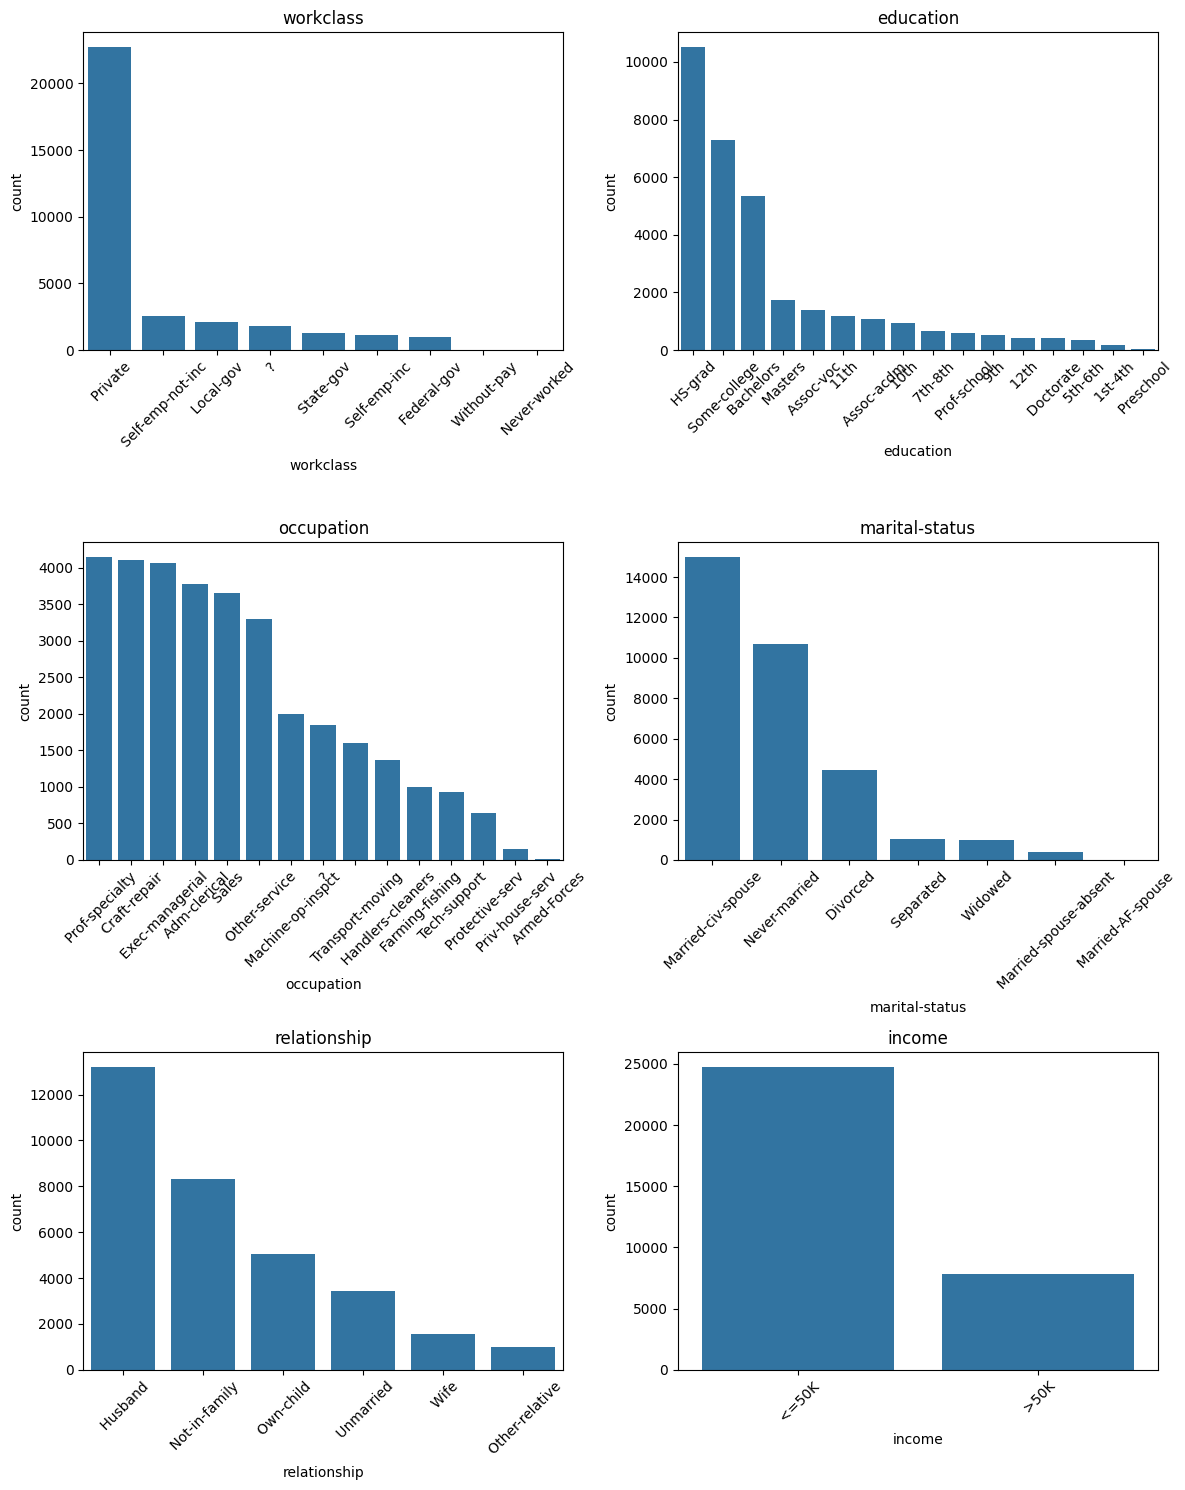

In [230]:

columns_to_plot = ['workclass', 'education','occupation','marital-status','relationship','income']  

n_cols = 2  # columnas por fila
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols  # filas necesarias

plt.figure(figsize=(n_cols*6, n_rows*5))

for i, col in enumerate(columns_to_plot):
    plt.subplot(n_rows, n_cols, i+1)
    sns.countplot(data=income_data, x=col, order=income_data[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

In [231]:
income_data.groupby('native-country').size().sort_values(ascending=False)
# la gran mayoria son de USA

native-country
United-States                 29170
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France       

In [232]:
# voy a eliminar los casos con ? en cualquier columna
income_data = income_data.query(
    "~`native-country`.str.contains(r'\?', na=False)"
)
income_data = income_data.query(
    "~`workclass`.str.contains(r'\?', na=False)"
)
income_data = income_data.query(
    "~`occupation`.str.contains(r'\?', na=False)"
)
print("Filas tras filtrar por pais faltante:", income_data.shape[0])

Filas tras filtrar por pais faltante: 30162


In [233]:
income_data.groupby('native-country').size().sort_values(ascending=False)
# la gran mayoria son de USA

native-country
United-States                 27504
Mexico                          610
Philippines                     188
Germany                         128
Puerto-Rico                     109
Canada                          107
El-Salvador                     100
India                           100
Cuba                             92
England                          86
Jamaica                          80
South                            71
Italy                            68
China                            68
Dominican-Republic               67
Vietnam                          64
Guatemala                        63
Japan                            59
Poland                           56
Columbia                         56
Taiwan                           42
Haiti                            42
Iran                             42
Portugal                         34
Nicaragua                        33
Peru                             30
Greece                           29
France       

In [234]:
income_data.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


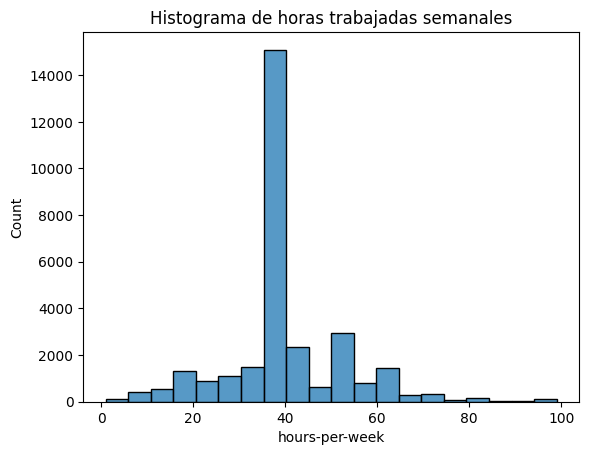

In [235]:
sns.histplot(data=income_data, x='hours-per-week',bins=20)  
plt.title("Histograma de horas trabajadas semanales")
plt.show()

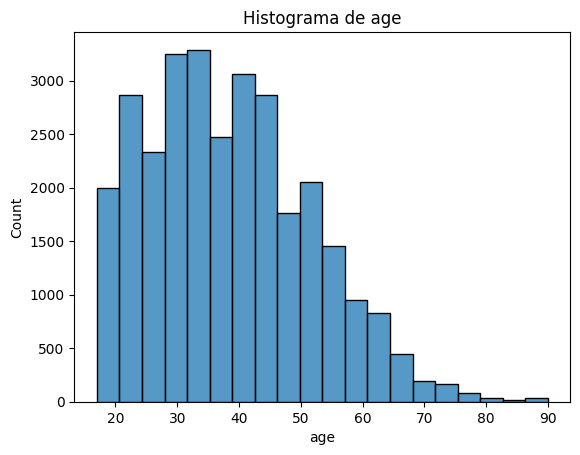

In [236]:
sns.histplot(data=income_data, x='age',bins=20)  
plt.title("Histograma de age")
plt.show()

In [237]:
income_data.groupby('income').size()
# el 23% en > 50k

income
<=50K    22654
>50K      7508
dtype: int64

In [238]:
income_data['income'] = (
    income_data['income']
        .str.strip()
        .str.replace('.', '', regex=False)
        .map({'<=50K': 0, '>50K': 1})
)

In [239]:
income_data.groupby('income').size()

income
0    22654
1     7508
dtype: int64

# Preparacion de datos previo a entrenamiento

In [240]:
# Ver porcentaje de valores faltantes por columna
income_data.isnull().mean() * 100


age               0.0
workclass         0.0
education         0.0
education-num     0.0
marital-status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital-gain      0.0
capital-loss      0.0
hours-per-week    0.0
native-country    0.0
income            0.0
dtype: float64

Separo variables de la target

In [241]:
y = income_data['income']  # 1 si <=50K, 0 si no >50k
X = income_data.drop(columns=['income'])

Identificar categoricas y numericas

Codificar categoricas

In [242]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [243]:
cat_cols = X.select_dtypes(include='object').columns.tolist()  # categóricas
num_cols = X.select_dtypes(include='number').columns.tolist()  # numéricas

# Preprocesador: solo OneHot para categóricas, numéricas tal cual
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ]
)

# Aplicar transformación
X_processed_array = preprocessor.fit_transform(X)

# Crear nombres de columnas
columns = list(preprocessor.get_feature_names_out())
# Renombrar numéricas para quitar 'remainder__'
columns = [c.replace('num__', '').replace('cat__', '') for c in columns]

# Convertir a DataFrame
X_processed = pd.DataFrame(X_processed_array, columns=columns, index=X.index)

print("Columnas procesadas:", X_processed.shape[1])

Columnas procesadas: 95


In [244]:
X_processed.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,workclass_ Without-pay,education_ 11th,education_ 12th,education_ 1st-4th,education_ 5th-6th,education_ 7th-8th,education_ 9th,education_ Assoc-acdm,education_ Assoc-voc,education_ Bachelors,education_ Doctorate,education_ HS-grad,education_ Masters,education_ Preschool,education_ Prof-school,education_ Some-college,marital-status_ Married-AF-spouse,marital-status_ Married-civ-spouse,marital-status_ Married-spouse-absent,marital-status_ Never-married,marital-status_ Separated,marital-status_ Widowed,occupation_ Armed-Forces,occupation_ Craft-repair,occupation_ Exec-managerial,occupation_ Farming-fishing,occupation_ Handlers-cleaners,occupation_ Machine-op-inspct,occupation_ Other-service,occupation_ Priv-house-serv,occupation_ Prof-specialty,occupation_ Protective-serv,occupation_ Sales,occupation_ Tech-support,occupation_ Transport-moving,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Male,native-country_ Canada,native-country_ China,native-country_ Columbia,native-country_ Cuba,native-country_ Dominican-Republic,native-country_ Ecuador,native-country_ El-Salvador,native-country_ England,native-country_ France,native-country_ Germany,native-country_ Greece,native-country_ Guatemala,native-country_ Haiti,native-country_ Holand-Netherlands,native-country_ Honduras,native-country_ Hong,native-country_ Hungary,native-country_ India,native-country_ Iran,native-country_ Ireland,native-country_ Italy,native-country_ Jamaica,native-country_ Japan,native-country_ Laos,native-country_ Mexico,native-country_ Nicaragua,native-country_ Outlying-US(Guam-USVI-etc),native-country_ Peru,native-country_ Philippines,native-country_ Poland,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,0.042796,1.128918,0.146092,-0.218586,-0.077734,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.880288,1.128918,-0.147445,-0.218586,-2.331531,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.033340,-0.439738,-0.147445,-0.218586,-0.077734,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.108695,-1.224066,-0.147445,-0.218586,-0.077734,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.794697,1.128918,-0.147445,-0.218586,-0.077734,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0

Dividir train-test

In [245]:
from sklearn.model_selection import train_test_split

In [246]:
# Divido 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, 
    y, 
    test_size=0.2,         # 20% de los datos para test
    random_state=42,        # semilla para reproducibilidad
    stratify=y              # mantiene la proporción de clases
)

Armado del modelo

In [247]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [248]:
svm_model = SVC(
    kernel='rbf',     # kernel más usado
    C=1.0,            # regularización
    gamma='scale',    # valor por defecto recomendable
    random_state=42,
    class_weight='balanced',
)

svm_model.fit(X_train, y_train)

SVC(class_weight='balanced', random_state=42)

Evaluacion

In [249]:
y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))


Accuracy: 0.8103762638819825

Matriz de confusión:
 [[3603  928]
 [ 216 1286]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.94      0.80      0.86      4531
           1       0.58      0.86      0.69      1502

    accuracy                           0.81      6033
   macro avg       0.76      0.83      0.78      6033
weighted avg       0.85      0.81      0.82      6033



Veo la importancia de los features

In [250]:
from sklearn.inspection import permutation_importance

In [ ]:
result = permutation_importance(
    svm_model,
    X_test,
    y_test,
    n_repeats=3,
    random_state=42,
    scoring='f1',
    n_jobs=-1    
)

importances = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

importances.head(10)

,feature,importance_mean,importance_std
27,marital-status_ Married-civ-spouse,0.069035,0.004065
1,education-num,0.045310,0.005853
2,capital-gain,0.035606,0.001316
0,age,0.021040,0.001146
4,hours-per-week,0.012513,0.002634
3,capital-loss,0.005213,0.001541
38,occupation_ Other-service,0.005075,0.000866
6,workclass_ Private,0.004859,0.001506
35,occupation_ Farming-fishing,0.004475,0.000655
49,relationship_ Wife,0.003591,0.000893


### Interpretación de las 3 características más importantes

Según el análisis de importancia por permutación, las tres variables que más influyen en la predicción de ingresos mayores a 50K son:

1. **Estado civil: `Married-civ-spouse`**  
   Ser casado con cónyuge presente resulta ser la característica más relevante. En nuestro modelo, esto indica que las personas que se encuentran en esta situación tienen más probabilidades de tener ingresos altos.

2. **Años de educación: `education-num`**  
   El nivel educativo también tiene un peso importante. Cuantos más años de educación tenga una persona, mayor es la probabilidad de que sus ingresos superen los 50K, lo que coincide con la intuición y la literatura económica.

3. **Ganancias de capital: `capital-gain`**  
   Las ganancias de capital (por inversiones o venta de activos) son otra variable clave. Valores altos en esta característica se asocian fuertemente con ingresos elevados.

En conjunto, estas tres variables muestran que el modelo tiende a asociar ingresos altos con personas que tienen **estabilidad familiar, mayor educación y capacidad de generar ingresos adicionales por capital**.
